<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/sources.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Astronomical Data Sources**

In [ ]:
!pip install astropy photutils astroquery lightkurve -q

#### **MAST**

**MAST (Mikulski Archive for Space Telescopes)**

* Accessible via astroquery.mast with data from James Webb in FITS format
* The [Mikulski Archive for Space Telescopes](https://en.m.wikipedia.org/wiki/Mikulski_Archive_for_Space_Telescopes) (MAST) is an astronomical data archive. The archive brings together data from the visible, ultraviolet, and near-infrared wavelength regimes
  * MAST Observations: Millions of observations from Pan-STARRS, JWST, Hubble, Kepler, GALEX, IUE, FUSE, and more.
  * Virtual Observatory: Search thousands of astronomical data archives from around the world for images, spectra, and catalogs.
  * Hubble Source Catalog: A master catalog with a hundred million measurements of objects in Hubble images.
  * MAST Catalogs: Access to catalog data such as Gaia and TESS Input Catalog, with more coming soon.
* Homepage: https://mast.stsci.edu/portal/Mashup/Clients/Mast/Portal.html
* In October 2020 the project released the largest and most detailed 3D maps of the Universe, the classification and photometric redshift catalog "PS1-STRM". The data was created using neural networks and combines data from the Sloan Digital Sky Survey and others. Users can query the dataset online or download it in its entirety of ~300GB: https://archive.stsci.edu/hlsp/ps1-strm


In [30]:
# Access infrared data from Kepler instruments
from astroquery.mast import Observations

# Set up the query parameters
obs_table = Observations.query_criteria(
    obs_collection='Kepler'
)

# Display the results
print(obs_table)

intentType obs_collection provenance_name instrument_name project ... mtFlag srcDen obsid  objID 
---------- -------------- --------------- --------------- ------- ... ------ ------ ------ ------
   science         Kepler          Kepler          Kepler  Kepler ...     -- 5885.0 390043 616921
   science         Kepler          Kepler          Kepler  Kepler ...     -- 5885.0 390044 616922
   science         Kepler          Kepler          Kepler  Kepler ...     -- 5885.0 390045 616923
   science         Kepler          Kepler          Kepler  Kepler ...     -- 5885.0 390046 616924
   science         Kepler          Kepler          Kepler  Kepler ...     -- 5885.0 390047 616925
   science         Kepler          Kepler          Kepler  Kepler ...     -- 5885.0 390048 616926
   science         Kepler          Kepler          Kepler  Kepler ...     -- 5885.0 390049 616927
   science         Kepler          Kepler          Kepler  Kepler ...     -- 5885.0 390050 616928
   science         K

In [31]:
data = Observations.get_product_list(obs_table[0])
unique_products = len(set(data['productFilename']))
print(f"Number of unique products: {unique_products}")

Number of unique products: 5


In [7]:
# Access infrared data from JWS instruments
from astroquery.mast import Observations

# Set up the query parameters
obs_table = Observations.query_criteria(
    obs_collection='JWST',           # Specific to JWST
    instrument_name=['NIRCam', 'MIRI', 'NIRSpec', 'NIRISS', 'FGS']
)

# Display the results
print(obs_table)

 intentType obs_collection provenance_name instrument_name ... mtFlag srcDen   obsid     objID  
----------- -------------- --------------- --------------- ... ------ ------ --------- ---------
    science           JWST         CALJWST         NIRSPEC ...  False    nan 107458509 204963674
    science           JWST         CALJWST            MIRI ...  False    nan 102604820 215004479
calibration           JWST         CALJWST             FGS ...  False    nan  71739127 294621945
calibration           JWST         CALJWST             FGS ...  False    nan  78110357 317255586
calibration           JWST         CALJWST             FGS ...  False    nan  71774526 317392654
calibration           JWST         CALJWST             FGS ...  False    nan  71752546 317392663
calibration           JWST         CALJWST             FGS ...  False    nan  71774896 317557360
calibration           JWST         CALJWST             FGS ...  False    nan  71775531 317557535
calibration           JWST    

In [16]:
# Assuming you've selected specific observations (first one for this example)
data = Observations.get_product_list(obs_table[0])

In [17]:
# Instead of downloading, just count unique products
unique_products = len(set(data['productFilename']))

# Print the count of unique products
print(f"Number of unique products: {unique_products}")

Number of unique products: 803


In [18]:
# Show the available data products
print(data)

  obsID   obs_collection dataproduct_type ... dataRights calib_level   filters   
--------- -------------- ---------------- ... ---------- ----------- ------------
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
 97278823           JWST             cube ...     PUBLIC           2 F290LP;G395H
      ...       

In [ ]:
# Download all data
# Observations.download_products(data)

In [21]:
# Select the first few products to download (e.g., first 5 products)
subset = data[:5]  # Adjust the number as needed

# Download the selected data products
Observations.download_products(subset)

Local Path,Status,Message,URL
str95,str8,object,object
./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq1_2022285233912_cal.fits,COMPLETE,None,None
./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq1_2022285233957_cal.fits,COMPLETE,None,None
./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq2_2022285233914_cal.fits,COMPLETE,None,None
./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq2_2022285233959_cal.fits,COMPLETE,None,None
./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-fg_2022285235710_cal.fits,COMPLETE,None,None


In [19]:
# Filter table by column value, based on specific criteria, e.g. only observations using NIRCam
nircam_obs = obs_table[obs_table['instrument_name'] == 'MIRI']
print(nircam_obs)

intentType obs_collection provenance_name instrument_name ... mtFlag srcDen   obsid     objID  
---------- -------------- --------------- --------------- ... ------ ------ --------- ---------
   science           JWST         CALJWST            MIRI ...  False    nan 102604820 215004479


In [146]:
# Specify the path to the FITS file
fits_file = './mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq1_2022285233912_cal.fits'

# Open the FITS file
hdul = fits.open(fits_file)

# Print the file information
hdul.info()

Filename: ./mastDownload/JWST/jw01864003001_03101_00001_nrs1/jw01864003001_gs-acq1_2022285233912_cal.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     161   ()      
  1  SCI           1 ImageHDU        56   (128, 128, 6)   float32   
  2  ERR           1 ImageHDU        10   (128, 128, 6)   float32   
  3  DQ            1 ImageHDU        11   (128, 128)   int32 (rescales to uint32)   
  4  ASDF          1 BinTableHDU     11   1R x 1C   [398172B]   


In [143]:
# Access the primary HDU (Header/Data Unit) to get the data
primary_hdu = hdul[0]
data = primary_hdu.data

# Display the header to learn more about the file
print(primary_hdu.header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  DATE    = '2022-10-13T06:07:44.279' / UTC date file created                     ORIGIN  = 'STSCI   '           / Organization responsible for creating file     TIMESYS = 'UTC     '           / principal time system for time-related keywordsTIMEUNIT= 's       '           / Default unit applicable to all time values     FILENAME= 'jw01864003001_gs-acq1_2022285233912_cal.fits' / Name of the file     SDP_VER = '2022_3a '           / Data processing software version number        PRD_VER = 'PRDOPSSOC-058'      / S&OC PRD version number used in data processingOSS_VER = '008.004.014.000'    / Observatory Scheduling Software (OSS) version nCAL_VER = '1.7.2   '           / Calibra

In [144]:
# Check if there is data
if data is not None:
    # Show the dimensions of the data
    print(f"Data shape: {data.shape}")

    # Display the image if it is 2D
    if data.ndim == 2:
        plt.figure(figsize=(10, 8))
        plt.imshow(data, origin='lower', cmap='viridis')
        plt.colorbar()
        plt.title("All Sky ROSAT FITS Image")
        plt.show()
    else:
        print("Data is not 2D, unable to display as an image.")
else:
    print("No data found in the primary HDU.")

# Close the FITS file after you're done
hdul.close()

No data found in the primary HDU.


#### **Lightcurve**

https://colab.research.google.com/github/lightkurve/lightkurve/blob/main/docs/source/tutorials/1-getting-started/plotting-target-pixel-files.ipynb#scrollTo=px3Cl_ZzY4m6




https://github.com/deltorobarba/astrophysics/blob/main/exoplanet_kepler10.ipynb
* Lightcurve datalist = lk.search_targetpixelfile("Kepler-10")
*  Either select TPFs from list returned by search_targetpixelfile(), or use mission keyword argument when searching.

There is a difference between a Target Pixel File (TPF) and a FITS file in astronomy, although they are closely related:

* **FITS (Flexible Image Transport System)** is a standard file format widely used in astronomy for storing and exchanging image data and related information. It's like a container that can hold various types of astronomical data, including images, tables, and headers with metadata.

* **TPF (Target Pixel File)** is a specific type of FITS file used by the Transiting Exoplanet Survey Satellite (TESS) mission. It contains a series of images focused on a particular target star and its surrounding pixels. These images are used to create light curves, which show how the brightness of the star changes over time, helping astronomers detect exoplanets.

**In essence:**

* FITS is a general-purpose format for astronomical data.
* TPF is a specialized FITS file used by TESS for storing time-series images of target stars.

All TPFs are FITS files, but not all FITS files are TPFs. TPFs have a specific structure and contain specific information relevant to TESS observations, while FITS files can hold a broader range of astronomical data.


In [127]:
from astropy import units as u
import lightkurve as lk
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
search_result = lk.search_targetpixelfile("Kepler-8", author="Kepler", quarter=4, cadence="long")
search_result

https://heasarc.gsfc.nasa.gov/docs/tess/Target-Pixel-File-Tutorial.html

In [129]:
search_result = lk.search_targetpixelfile('TIC 307210830')
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 05,2018,SPOC,120,307210830,0.0
1,TESS Sector 02,2018,SPOC,120,307210830,0.0
2,TESS Sector 12,2019,SPOC,120,307210830,0.0
3,TESS Sector 11,2019,SPOC,120,307210830,0.0
4,TESS Sector 10,2019,SPOC,120,307210830,0.0
5,TESS Sector 09,2019,SPOC,120,307210830,0.0
6,TESS Sector 08,2019,SPOC,120,307210830,0.0
7,TESS Sector 29,2020,SPOC,20,307210830,0.0
8,TESS Sector 28,2020,SPOC,20,307210830,0.0


In [137]:
search_result[1]

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 02,2018,SPOC,120,307210830,0.0


In [130]:
tpf_file = search_result[1].download(quality_bitmask='default')
tpf_file

TessTargetPixelFile(TICID: 307210830)

In [134]:
tpf_file = lk.search_targetpixelfile('TIC 307210830', mission="TESS", sector=5).download(quality_bitmask='default')

/usr/local/lib/python3.10/dist-packages/lightkurve/search.py:424: LightkurveWarning: Warning: 2 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


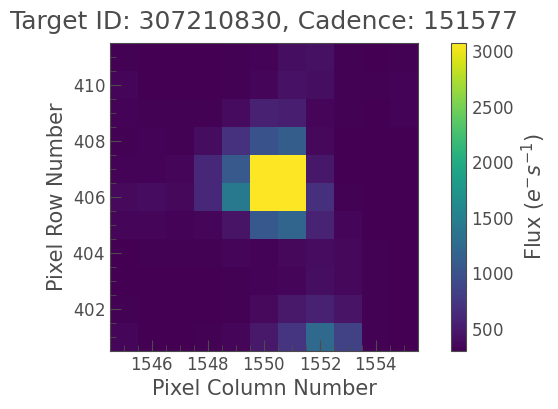

In [135]:
%matplotlib inline
tpf_file.plot();

In [136]:
tpf_file.get_header(ext=0)

SIMPLE  =                    T / conforms to FITS standards                     
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T / file contains extensions                       
NEXTEND =                    3 / number of standard extensions                  
EXTNAME = 'PRIMARY '           / name of extension                              
EXTVER  =                    1 / extension version number (not format version)  
SIMDATA =                    F / file is based on simulated data                
ORIGIN  = 'NASA/Ames'          / institution responsible for creating this file 
DATE    = '2020-12-16'         / file creation date.                            
TSTART  =    1437.988293513621 / observation start time in BTJD                 
TSTOP   =    1464.287307465899 / observation stop time in BTJD                  
DATE-OBS= '2018-11-15T11:41:

#### **IRSA**

**NASA/IPAC Infrared Science Archive (IRSA)**

* Accessible via from astroquery.ipac.irsa import Irsa https://astroquery.readthedocs.io/en/latest/ipac/irsa/irsa.html
* Keys: The keys in the dictionary are short identifiers or names for each catalog (e.g., 'spitzer.lvl_mips', 'wise.wise_allsky_4band_p1bm_frm'). These identifiers are what you'll use to specify the catalog in other astroquery functions when you want to query or retrieve data.
* Values: The values associated with each key are more descriptive names or explanations of the corresponding catalog (e.g., 'Spitzer LVL MIPS image Metadata', 'WISE Post-Cryo Single Exposure (L1b) Image Inventory Table').

In [32]:
from astroquery.ipac.irsa import Irsa

# Check available catalogs
catalogs = Irsa.list_catalogs()
print(catalogs)

{'twomass.full_images': '2MASS Full Survey Images', 'pt_src_6x2': "2MASS 6X w/LMC/SMC Point Source Working Database / Catalog (<a href='/applications/Gator/GatorAid/2MASS/6xcat.README.html' target='doc'>README</a>)", 'sixxf_info': '2MASS 6X w/LMC/SMC Merged Point Source Information Table', 'sixxf_link': '2MASS 6X w/LMC/SMC Merged Point Source Link Table', 'ext_src_6x2': "2MASS 6X w/LMC/SMC Extended Source Working Database / Catalog (<a href='/applications/Gator/GatorAid/2MASS/6xcat.README.html' target='doc'>README</a>)", 'esixxf_info': '2MASS 6X w/LMC/SMC Merged Extended Source Information Table', 'esixxf_link': '2MASS 6X w/LMC/SMC Merged Extended Source Link Table', 'pscan_dat_6x2': '2MASS 6X w/LMC/SMC Scan Info', 'coadd_dat_6x2': '2MASS 6X w/LMC/SMC Atlas Image Info', 'twomass.sixx_full_images': "2MASS Six-times (6x) Full Images (<a href='/applications/Radar/IM/2massImg.html' target='doc'>README</a>)", 'twomass.sixx_catalog_images': "2MASS Six-times (6x) Catalog Images (<a href='/app

In [138]:
from astroquery.ipac.irsa import Irsa

# Check available catalogs
catalogs = Irsa.list_catalogs()

# Filter for Spitzer catalogs
spitzer_catalogs = {key: value for key, value in catalogs.items() if 'spitzer' in key}

# Display the Spitzer catalogs
print(spitzer_catalogs)

{'spitzer.taurus_irac_ch1': 'Spitzer Taurus IRAC Ch1 Image Metadata', 'spitzer.taurus_irac_ch2': 'Spitzer Taurus IRAC Ch2 Image Metadata', 'spitzer.taurus_irac_ch3': 'Spitzer Taurus IRAC Ch3 Image Metadata', 'spitzer.taurus_irac_ch4': 'Spitzer Taurus IRAC Ch4 Image Metadata', 'spitzer.taurus_mips_24': 'Spitzer Taurus MIPS 24um Image Metadata', 'spitzer.taurus_mips_70': 'Spitzer Taurus MIPS 70um Image Metadata', 'spitzer.taurus_mips_160': 'Spitzer Taurus MIPS 160um Image Metadata', 'spitzer.taurus_images': 'Finishing the Spitzer Map of the Taurus Molecular Clouds (Taurus 2) Images', 'spitzer.frontier_images': 'Frontier Fields Images', 'spitzer.elflock_atlas': 'ELFLock: The Eureka LBNL Far-Infrared Lockman Hole (ELFLock) Map', 'spitzer.srelics_images': 'Spitzer Reionization Lensing Cluster Survey (SRELICS) Images', 'spitzer.m83m33_spectra': 'M83M33 Spectra', 'spitzer.lvl_mips': 'Spitzer LVL MIPS image Metadata', 'spitzer.lvl_irac': 'Spitzer LVL IRAC image Metadata', 'spitzer.lvl_halpha':

In [141]:
print('spitzer.s4g_images')

spitzer.s4g_images


#### **SDSS**

* Accessible via from astroquery.sdss import SDSS with data from James Webb in FITS format, https://astroquery.readthedocs.io/en/latest/sdss/sdss.html
* Der [Sloan Digital Sky Survey](https://de.m.wikipedia.org/wiki/Sloan_Digital_Sky_Survey) (SDSS) ist eine Durchmusterung eines Drittels des Himmels durch Aufnahmen bei fünf Wellenlängen und nachfolgende Spektroskopie einzelner Objekte.
* https://skyserver.sdss.org/dr5/en/sdss/data/data.asp

**Plate**: SDSS uses aluminum plates with holes drilled in them to precisely position optical fibers. Each plate corresponds to a specific region of the sky. The plate number is a unique identifier for that particular plate.

**FiberID**: Each hole on a plate is connected to an optical fiber that collects light from a single object (e.g., a galaxy, star, or quasar).
The fiberID is a number that identifies the specific fiber on that plate.

Together, plate and fiberID pinpoint a unique spectrum within the SDSS dataset. When you see plate = 2345 and fiberID = 572, it means you're referring to the spectrum collected by the 572nd fiber on the 2345th spectroscopic plate used by SDSS.

In [79]:
from astroquery.sdss import SDSS
from astropy.io import fits

# Specify the plate and fiber ID of the spectrum you want
plate = 1234  # Replace with a valid plate number
fiberID = 567  # Replace with a valid fiber ID

# Retrieve the spectrum
sp = SDSS.get_spectra(plate=plate, fiberID=fiberID)

# Access the HDUList (it's a list containing one element)
hdulist = sp[0]

# Save the FITS file (optional)
fits_file = hdulist.writeto('sdss_spectrum.fits', overwrite=True)

# Access the spectral data and header
data = hdulist[0].data
header = hdulist[0].header

# Print some information from the header
print(f"Telescope: {header['TELESCOP']}")
print(f"MJD: {header['MJD']}")

Telescope: SDSS 2.5-M
MJD: 52724


In [88]:
from astroquery.sdss import SDSS
from astropy.io import fits

# Specify the plate and fiber ID of the spectrum you want
plate = 3861  # Example with data
fiberID = 901  # Example with data

# Retrieve the spectrum
sp = SDSS.get_spectra(plate=plate, fiberID=fiberID)

if sp is not None:  # Check if data was found
    hdulist = sp[0]

    # Save the FITS file (optional) - Note: No assignment here
    filename = 'sdss_spectrum.fits'  # Store the filename
    hdulist.writeto(filename, overwrite=True)

    # Open the FITS file using the filename
    hdul = fits.open(filename)

    # Print the file information
    hdul.info()

    # Access the spectral data and header
    data = hdulist[0].data
    header = hdulist[0].header

    # Print some information from the header
    print(f"Telescope: {header['TELESCOP']}")
    print(f"MJD: {header['MJD']}")

else:
    print(f"No data found for plate={plate} and fiberID={fiberID}")

Filename: sdss_spectrum.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     112   ()      
  1  COADD         1 BinTableHDU     26   4614R x 8C   [E, E, E, J, J, E, E, E]   
  2  SPALL         1 BinTableHDU    488   1R x 236C   [27A, 14A, 4A, E, E, J, J, E, J, E, E, E, K, K, K, K, K, K, K, K, K, B, B, J, I, 5E, 5E, J, J, J, J, 7A, 7A, 16A, D, D, 6A, 21A, E, E, E, J, E, 24A, 10J, J, 10E, E, E, E, E, E, E, J, E, E, E, J, 5E, E, E, 10E, 10E, 10E, 5E, 5E, 5E, 5E, 5E, J, J, E, E, E, E, E, E, 16A, 9A, 12A, E, E, E, E, E, E, E, E, J, E, E, J, J, 6A, 21A, E, 35E, K, 19A, 19A, 19A, B, B, B, I, 3A, B, I, I, I, I, J, E, J, J, E, E, E, E, E, E, E, E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5J, 5J, 5J, 5E, 5J, 75E, 75E, 5E, 5E, 5E, 5J, 5E, D, D, D, D, D, D, D, D, D, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5E, 5

In [90]:
print(repr(hdul[0].header))  # Primary HDU header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
TELESCOP= 'SDSS 2.5-M'         / Sloan Digital Sky Survey                       
FLAVOR  = 'science '           / exposure type, SDSS spectro style              
BOSSVER = 'v2_1_6  '           / ICC version                                    
MJD     =                55274 / APO fMJD day at start of exposure              
MJDLIST = '55274   '           /                                                
RA      =           208.737257 / RA of telescope boresight (deg)                
DEC     =            32.561874 / Dec of telescope boresight (deg)               
EQUINOX =              2000.00 /                                                
RADECSYS= 'FK5     '        

In [91]:
print(repr(hdul[1].header))  # Science data HDU header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   32 / length of dimension 1                          
NAXIS2  =                 4614 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    8 / number of table fields                         
TTYPE1  = 'flux    '                                                            
TFORM1  = 'E       '                                                            
TTYPE2  = 'loglam  '                                                            
TFORM2  = 'E       '                                                            
TTYPE3  = 'ivar    '        

In [86]:
# Check if there is data
if data is not None:
    # Show the dimensions of the data
    print(f"Data shape: {data.shape}")

    # Display the image if it is 2D
    if data.ndim == 2:
        plt.figure(figsize=(10, 8))
        plt.imshow(data, origin='lower', cmap='viridis')
        plt.colorbar()
        plt.title("FITS data")
        plt.show()
    else:
        print("Data is not 2D, unable to display as an image.")
else:
    print("No data found in the primary HDU.")

# Close the FITS file after you're done
hdul.close()

No data found in the primary HDU.


In [54]:
# Perform an individual object cross-ID with SDSS

from astroquery.sdss import SDSS
from astropy import coordinates as coords

pos = coords.SkyCoord('0h8m05.63s +14d50m23.3s', frame='icrs')
xid = SDSS.query_region(pos, radius='5 arcsec', spectro=True)
print(xid)

       ra              dec               objid        run  ... fiberID     specobjid      run2d
---------------- ---------------- ------------------- ---- ... ------- ------------------ -----
2.02344596573482 14.8398237551311 1237652943176138868 1739 ...     160 845594848269461504    26


If we’d like to download spectra and/or images for our match, we have all the information we need in the elements of “xid” from the above example.

In [89]:
sp = SDSS.get_spectra(matches=xid)
im = SDSS.get_images(matches=xid, band='g')

In [56]:
from astroquery.sdss import SDSS
print(SDSS.AVAILABLE_TEMPLATES)

{'star_O': 0, 'star_OB': 1, 'star_B': 2, 'star_A': [3, 4], 'star_FA': 5, 'star_F': [6, 7], 'star_G': [8, 9], 'star_K': 10, 'star_M1': 11, 'star_M3': 12, 'star_M5': 13, 'star_M8': 14, 'star_L1': 15, 'star_wd': [16, 20, 21], 'star_carbon': [17, 18, 19], 'star_Ksubdwarf': 22, 'galaxy_early': 23, 'galaxy': [24, 25, 26], 'galaxy_late': 27, 'galaxy_lrg': 28, 'qso': 29, 'qso_bal': [30, 31], 'qso_bright': 32}


In [59]:
template = SDSS.get_spectral_template('qso')
template

[[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x7b924bad52d0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7b924bad5ff0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7b924bad6aa0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7b924bad6e90>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7b924bad7b20>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7b924ba626e0>]]

In [60]:
from astroquery.sdss import SDSS

# Get the spectral template (this part is the same as your code)
template = SDSS.get_spectral_template('qso')

# Access the HDUList object (since it's a list of one element)
hdulist = template[0]

# Explore the HDUList
for i, hdu in enumerate(hdulist):
    print(f"HDU {i}: {hdu.name}, type: {type(hdu)}")

# Access data in specific HDUs
# Example: if the data you need is in the first HDU
data = hdulist[0].data
header = hdulist[0].header


HDU 0: PRIMARY, type: <class 'astropy.io.fits.hdu.image.PrimaryHDU'>
HDU 1: , type: <class 'astropy.io.fits.hdu.table.BinTableHDU'>
HDU 2: , type: <class 'astropy.io.fits.hdu.table.BinTableHDU'>
HDU 3: , type: <class 'astropy.io.fits.hdu.table.BinTableHDU'>
HDU 4: , type: <class 'astropy.io.fits.hdu.table.BinTableHDU'>
HDU 5: , type: <class 'astropy.io.fits.hdu.table.BinTableHDU'>


In [62]:
from astroquery.sdss import SDSS
result = SDSS.query_photoobj(run=5714, camcol=6)
print(result[:5])

       ra              dec               objid        run  rerun camcol field
---------------- ---------------- ------------------- ---- ----- ------ -----
22.2574304026371  8.4317548890373 1237670017262485671 5714   301      6    21
23.3724928783588 8.32576993102749 1237670017262944491 5714   301      6    28
25.4801226435058 8.27642390025019 1237670017263927330 5714   301      6    43
27.6054875371138 8.18675660092507 1237670017264779427 5714   301      6    56
36.1895219535201  7.6084623159047 1237670017268580401 5714   301      6   114


#### **Splatalogue**

* ALMA Spectral Line Catalog: Splatalogue
* https://astroquery.readthedocs.io/en/latest/splatalogue/splatalogue.html

pppp
* filename_1 = download_file("https://almascience.eso.org/dataPortal/member.uid___A001_X1465_X3a33.BrickMaser_sci.spw71.cube.I.manual.image.pbcor.fits" cache=True)
* https://github.com/deltorobarba/astrophysics/blob/main/spectroscopy_radio.ipynb


In [120]:
# This will return the complete Splatalogue chemical species list, including all isotopologues
from astroquery.splatalogue import Splatalogue
line_ids = Splatalogue.get_species_ids()

In [121]:
line_ids

{'00102 Ps - Positronium': '1369',
 '00502 HeH+ - Helium hydride cation': '1204',
 '00701 6LiH v=0 - Lithium Hydride': '599',
 '00702 6LiH v=1 - Lithium Hydride': '1175',
 '00802 LiH v=1 - Lithium Hydride': '1176',
 '00803 6LiD v=0 - Lithium Hydride': '503',
 '00804 6LiD v=1 - Lithium Hydride': '1177',
 '00901 LiD v=0 - Lithium Hydride': '476',
 '00902 LiD v=1 - Lithium Hydride': '1203',
 '01206 BH - Boron monohydride': '1205',
 '01402 N-atom - Atomic Nitrogen': '730',
 '01403 N atom - D-state - Atomic Nitrogen': '569',
 '01405 13CH - Methylidyne  ': '1329',
 '01406 CD - Methylidyne': '1330',
 '01407 13CH+ - methyliumylidene': '1371',
 '01502 CHD - Methylene radical': '21167',
 '01703 OH v=1 - Hydroxyl': '563',
 '01705 OH v=2 - Hydroxyl': '1066',
 '01708 OH- - Hydroxyl anion': '1068',
 '01711 CH3D - Monodeuterated Methane': '423',
 '01712 15NH2 - Amidogen': '21152',
 '01713 NHD - Amidogen': '21168',
 '01714 OH - ': '21285',
 '01803 OD - Hydroxyl': '543',
 '01804 OD- - Hydroxyl anion': 

In [122]:
CO_containing_species = Splatalogue.get_species_ids(species_regex='CO')
len(CO_containing_species)

105

In [ ]:
from astropy import units as u
CO1to0 = Splatalogue.query_lines(115.271*u.GHz, 115.273*u.GHz)
CO1to0.pprint(max_width=200)

In [ ]:
S = Splatalogue(energy_max=500,
   energy_type='eu_k', energy_levels=['Four'],
   line_strengths=['CDMSJPL'])
def trimmed_query(*args,**kwargs):
    columns = ('species_id', 'chemical_name', 'name', 'resolved_QNs',
               'orderedfreq',
               'aij',
               'upper_state_energy_K')
    table = S.query_lines(*args, **kwargs)[columns]
    table.sort('upper_state_energy_K')
    return table
trimmed_query(1*u.GHz,30*u.GHz,
    chemical_name='(H2.*Formaldehyde)|( HDCO )',
    energy_max=50)[:10].pprint(max_width=150)

In [124]:
from astroquery.splatalogue import Splatalogue
from astropy import units as u
from astropy.table import Table

min_freq = 88 * u.GHz
max_freq = 90 * u.GHz

try:
    result = Splatalogue.query_lines(min_frequency=min_freq,
                                     max_frequency=max_freq,
                                     chemical_name='CO',
                                     line_lists=['cdms'])  # Use a specific line list like 'cdms'

    # Check if the result is a valid Astropy table
    if isinstance(result, Table):
        print(result)
    else:
        print("Received an invalid or empty response from Splatalogue.")

except Exception as e:
    print(f"Error querying Splatalogue: {e}")


Error querying Splatalogue: Number of header columns (1) inconsistent with data columns (2) at data line 13
Header values: ['<!-- start of nrao-header.html -->']
Data values: ['<a href="http', '//www.nrao.edu/">']


In [119]:
from astroquery.splatalogue import Splatalogue
Splatalogue.clear_cache()

In [ ]:
CO2to1 = Splatalogue.query_lines(1*u.mm, 2*u.mm, chemical_name=" CO ")
CO2to1.pprint(max_width=200)

In [ ]:
ha_result = Splatalogue.query_lines(84*u.GHz, 115*u.GHz, chemical_name='Hα')
ha_result.pprint(max_width=200)

In [ ]:
from astroquery.splatalogue import Splatalogue
from astropy import units as u

# Define the frequency range using Astropy units
min_freq = 88 * u.GHz  # GHz
max_freq = 90 * u.GHz  # GHz

# Query the Splatalogue database for spectral lines within the frequency range
result = Splatalogue.query_lines(min_frequency=min_freq,
                                 max_frequency=max_freq,
                                 chemical_name='CO',  # Search for carbon monoxide (CO)
                                 line_lists=['cdms'])  # Use the CDMS line list

# Display the result
print(result)


In [ ]:
from astroquery.splatalogue import Splatalogue

# Define the frequency range in GHz (you can adjust this to your needs)
min_freq = 88.0  # GHz
max_freq = 90.0  # GHz

# Query the Splatalogue database for spectral lines within the frequency range
result = Splatalogue.query_lines(min_frequency=88e9,
                                 max_frequency=90e9,
                                 chemical_name='H2O',  # Search for water vapor lines
#                                 chemical_id=285,      # Chemical ID (specific for certain molecules)
                                 energy_max=150,       # Set upper limit for energy level (in cm^-1)
#                                 intensity_min=-5,     # Minimum intensity (optional)
#                                 intensity_units='cd', # Unit for intensity (choose 'K' or 'cd')
#                                 line_list='lovas',    # Choose specific line list (e.g., 'lovas', 'cdms', etc.)
                                 show_qn_code=True)    # Display quantum number code


# Display the result
print(result)


In [ ]:
# To print the full table
print(result)

# To access specific columns (e.g., frequencies and intensities)
frequencies = result['Freq-GHz']
intensities = result['Log<sub>10</sub>(Aij)']

# To save the result to a CSV file
result.write('splatalogue_query_results.csv', format='csv', overwrite=True)


In [ ]:
from astroquery.splatalogue import Splatalogue

# Specify the frequency range (required)
min_frequency = 110 * u.GHz
max_frequency = 111 * u.GHz

# Query Splatalogue
# result = Splatalogue.query_lines(min_frequency, max_frequency, chemical_name='CO')

result = Splatalogue.query_lines(
    min_frequency, max_frequency,
    chemical_name='CO',
    line_lists=['JPL', 'CDMS'],
    line_strengths='Aij',
    energy_levels='EU_K',
    show_upper_degeneracy=True
)

# Print the result table
print(result)

#### VizieR

* VizieR web service
* from astroquery.vizier import Vizier
* https://astroquery.readthedocs.io/en/latest/vizier/vizier.html
* https://vizier.cds.unistra.fr/
* The VizieR service, hosted by the Centre de Données astronomiques de Strasbourg (CDS), is a powerful astronomical catalog service that provides access to a vast collection of published astronomical data. Think of it as a giant library of star catalogs, surveys, and observational data tables.

Primarily catalogs:
* VizieR focuses on providing access to a vast collection of published astronomical catalogs. It's like a comprehensive library of tables.
* Wide range of data: The catalogs in VizieR cover a wide range of wavelengths and data types, from optical to radio, and from surveys to individual object observations.
* Limited observation files: While VizieR does offer some FITS images and spectra, its primary focus is on catalog data. It might link to external archives where the full observations are stored.

Here's what makes VizieR special:

* **Comprehensive:** It boasts the most extensive library of published astronomical catalogs, with a focus on verified and enriched data. This means the data has undergone quality checks and may include additional information beyond the original publications.
* **Easy to use:**  It offers user-friendly web interfaces and tools for searching, selecting, and extracting data from the catalogs. You can search by object name, coordinates, criteria, or even browse through the catalog list.
* **Flexible output:** You can retrieve data in various formats, including plain text, HTML tables, and VOTable (a standard format for astronomical data exchange). This makes it compatible with other Virtual Observatory tools and services.
* **Connected to other resources:** VizieR is well-integrated with other astronomical services. It links to related data and resources like SIMBAD (for object identification) and Aladin (for interactive sky visualization).

**How is it useful for astronomers?**

* **Literature research:**  Quickly find relevant data tables from published papers.
* **Data compilation:** Gather data from multiple catalogs for a specific research project.
* **Cross-matching:**  Compare and combine data from different sources.
* **Target selection:** Identify objects with specific properties for observation.

**Key features:**

* **Catalog search:**  Search by catalog name, keyword, or astronomical object.
* **Data extraction:**  Extract specific data columns or rows based on your criteria.
* **Data filtering:** Filter data based on various parameters (e.g., magnitude, spectral type).
* **Cross-correlations:** Find objects in common between different catalogs.
* **VOTable support:** Export data in VOTable format for interoperability with other tools.

If you're working with astronomical catalogs and need to access published data, VizieR is an invaluable resource. It simplifies the process of finding, accessing, and working with the wealth of information available in the astronomical literature.


In [40]:
from astroquery.vizier import Vizier

catalog_list = Vizier.find_catalogs('hot jupiter exoplanet transit')
for k, v in catalog_list.items():
    print(k, ":", v.description)

J/ApJ/788/39 : Hot Jupiter exoplanets host stars EW and abundances (Teske+, 2014)
J/A+A/635/A122 : CoRoT-30b and CoRoT-31b radial velocity curves (Border+, 2020)
J/A+A/635/A205 : Ultra-hot Jupiter WASP-121b transits (Bourrier+, 2020)
J/AJ/157/217 : Transit times of five hot Jupiter WASP exoplanets (Bouma+, 2019)


In [51]:
from astroquery.vizier import Vizier

vizier = Vizier()
result = vizier.query_object("sirius")
print(result)

TableList with 426 tables:
	'0:METAobj' with 5 column(s) and 7 row(s) 
	'1:ReadMeObj' with 5 column(s) and 7 row(s) 
	'2:I/34/greenw2a' with 16 column(s) and 1 row(s) 
	'3:I/40/catalog' with 11 column(s) and 1 row(s) 
	'4:I/80/n30' with 13 column(s) and 1 row(s) 
	'5:I/82/catalog' with 11 column(s) and 1 row(s) 
	'6:I/87B/catalog' with 13 column(s) and 1 row(s) 
	'7:I/98A/catalog' with 20 column(s) and 1 row(s) 
	'8:I/98A/remarks' with 6 column(s) and 1 row(s) 
	'9:I/100A/w10' with 9 column(s) and 1 row(s) 
	'10:I/100A/w25' with 9 column(s) and 1 row(s) 
	'11:I/100A/w50' with 9 column(s) and 5 row(s) 
	'12:I/113A/catalog' with 10 column(s) and 1 row(s) 
	'13:I/131A/sao' with 11 column(s) and 1 row(s) 
	'14:I/143/fk4_1950' with 15 column(s) and 1 row(s) 
	'15:I/149A/catalog' with 6 column(s) and 1 row(s) 
	'16:I/193/ppm2' with 12 column(s) and 1 row(s) 
	'17:I/196/main' with 14 column(s) and 1 row(s) 
	'18:I/196/annex1' with 10 column(s) and 4 row(s) 
	'19:I/197A/tic' with 10 column(s) 

In [53]:
# Query an object
interesting_table = result['J/MNRAS/504/5813/tablec4']
print(interesting_table)

  Name     Evol    Brms    e_Brms  ... e_vsini                   Refs                   SimbadName
                 0.0001 T 0.0001 T ...  km / s                                                    
-------- ------- -------- -------- ... ------- ---------------------------------------- ----------
HD48915A A1V(MS)     0.20     0.10 ...     1.0 Petit et al. (2011), Royer et al. (2002)   HD48915A


In [52]:
# Query an object
interesting_table = result['IX/8/catalog']
print(interesting_table)

  _2XRS     RAB1950      DEB1950    Xname Box    Elow     Eup    Int   _RA.icrs     _DE.icrs  
                                          deg2   keV      keV    uJy                          
--------- ------------ ------------ ----- ---- -------- -------- --- ------------ ------------
06429-166 06 42 54.000 -16 39 00.00         --    0.200       --  -- 06 45 08.088 -16 42 11.29
06429-166 06 42 54.000 -16 39 00.00         --    0.150    2.500  -- 06 45 08.088 -16 42 11.29


In [45]:
# Query a region
from astroquery.vizier import Vizier
from astropy.coordinates import Angle
import astropy.units as u

result = Vizier.query_region("3C 273", radius=Angle(0.1, "deg"), catalog='GSC')
# result = Vizier.query_region("3C 273", radius="0d6m0s", catalog='GSC')
# result = Vizier.query_region("3C 273", radius=0.1*u.deg, catalog='GSC')

print(result)

TableList with 5 tables:
	'0:I/254/out' with 10 column(s) and 17 row(s) 
	'1:I/255/out' with 9 column(s) and 17 row(s) 
	'2:I/271/out' with 11 column(s) and 50 row(s) 
	'3:I/305/out' with 11 column(s) and 50 row(s) 
	'4:I/353/gsc242' with 35 column(s) and 50 row(s) 


#### Simbad

**SIMBAD (Set of Identifications, Measurements, and Bibliography for Astronomical Data)**

* from astroquery.simbad import Simbad
* https://astroquery.readthedocs.io/en/latest/simbad/simbad.html
* SIMBAD is a comprehensive database of astronomical objects. It's maintained by the Centre de Données astronomiques de Strasbourg (CDS) and is widely used by astronomers for object identification and information retrieval.
* **Object identification:** It provides basic information about astronomical objects like stars, galaxies, and planets, including their positions, names, and various identifiers used in different catalogs.
* **Cross-identification:** It helps resolve the issue of objects having multiple names or designations in different catalogs by linking them together.
* **Bibliographic data:** SIMBAD includes references to relevant publications for each object, allowing you to trace back the source of information.
* **Observational data:** It may contain some basic observational data like magnitudes, spectral types, and redshifts, but it primarily focuses on identification and cross-referencing.
* **Links to other resources:** SIMBAD is often connected to other astronomical services like VizieR (for accessing catalog data) and Aladin (for sky visualization).

**How is it useful for astronomers?**

* **Object disambiguation:** Determine if different names refer to the same object.
* **Literature search:** Find relevant publications for a specific object.
* **Data compilation:** Gather basic information for a set of objects.
* **Observing planning:**  Check if an object has been previously observed and what its properties are.

If you need to identify an astronomical object, find its various names, or access related publications, SIMBAD is an essential tool. It acts as a central hub for astronomical object information, helping researchers navigate the complexities of astronomical nomenclature and data.




#### **Telescopes**

**The Spitzer Space Telescope had three primary instruments for electromagnetic sensing, all operating in the infrared portion of the spectrum:**

* **Infrared Array Camera (IRAC):** This was Spitzer's main camera, and it took images in four infrared wavelengths simultaneously (3.6, 4.5, 5.8, and 8.0 microns). IRAC was used to study a wide variety of objects, including distant galaxies, star-forming regions, and exoplanets.

* **Infrared Spectrograph (IRS):**  This instrument was a spectrograph, meaning it split light into its component colors (wavelengths). This allowed astronomers to study the composition and physical properties of celestial objects by analyzing their spectral fingerprints. IRS operated in four modules covering a wavelength range of 5.3 to 40 microns.

* **Multiband Imaging Photometer for Spitzer (MIPS):** This instrument was both a camera and a spectrograph. It took images in three far-infrared wavelengths (24, 70, and 160 microns) and could also obtain spectra in the 50 to 100 micron range. MIPS was particularly useful for studying very cold objects, such as dust and gas clouds where stars are forming.

These three instruments working together allowed Spitzer to make groundbreaking discoveries in a wide range of astronomical fields, from our own solar system to the distant universe.


**The James Webb Space Telescope (JWST) has two following instruments for electromagnetic sensing:**

* **NIRCam** (Near-Infrared Camera):
  * **Primary imager for JWST:**  It's responsible for capturing the stunning images we see from Webb.
  * **Wavelength range:** Operates in the near-infrared range of 0.6 to 5 microns.
  * **Key functions:**
    * **Imaging:**  Provides high-resolution images of a wide variety of objects, including distant galaxies, star-forming regions, and planets.
    * **Coronagraphy:**  Blocks out the light from bright stars to reveal fainter objects like exoplanets orbiting them.
    * **Wide-field slitless spectroscopy:**  Can obtain spectra of multiple objects simultaneously.
* **MIRI (Mid-Infrared Instrument):**
  * **Longest wavelength instrument on JWST:**  Allows observation of cooler objects and those hidden by dust.
  * **Wavelength range:** Operates in the mid-infrared range of 5 to 28 microns.
  * **Key functions:**
    * **Imaging:**  Captures images of objects that are too cool to be seen in near-infrared light, such as distant galaxies, newly forming stars, and faint comets.
    * **Coronagraphy:**  Similar to NIRCam, it can block the light of stars to reveal fainter objects.
    * **Medium-resolution spectroscopy:**  Provides detailed information about the composition and physical properties of astronomical objects.
* **Why different infrared wavelengths?**
  * **Near-infrared light:**  Allows astronomers to see through dust clouds that obscure visible light, revealing stars and galaxies hidden within. It also helps study the redshift of light from distant objects.
  * **Mid-infrared light:**  Can detect cooler objects, such as dust and gas clouds where stars are forming. It also helps study the composition of these objects by analyzing their spectral fingerprints.
  * By combining the data from NIRCam and MIRI, astronomers can gain a more complete understanding of the universe, from the earliest galaxies to the formation of stars and planets.
* **NIRSpec** (Near-Infrared Spectrograph): This instrument is designed to obtain high-resolution spectra of astronomical objects, such as stars and galaxies, in the near-infrared wavelength range. It can observe up to 100 objects simultaneously, thanks to its microshutter array.
* (NIRISS/FGS) Near-Infrared Imager and Slitless Spectrograph/Fine Guidance Sensor: This instrument has two main functions:
  * **NIRISS**: It provides near-infrared imaging and spectroscopic capabilities, particularly for exoplanet studies and the analysis of the first light in the universe.
  * **FGS**: It ensures the precise pointing of the telescope, enabling the long exposures necessary for capturing faint objects.

**Hubble has three main science instruments:**

* **Wide Field Camera 3 (WFC3):** This is Hubble's main camera, and it's incredibly versatile. It observes in a wide range of wavelengths, from ultraviolet to near-infrared, allowing it to capture stunning images of everything from nearby star-forming regions to distant galaxies.

* **Cosmic Origins Spectrograph (COS):** This instrument is a spectrograph, meaning it splits light into its component colors. This allows astronomers to study the composition, temperature, and motion of celestial objects. COS is particularly good at observing faint objects, like distant quasars and the gas between galaxies.

* **Space Telescope Imaging Spectrograph (STIS):**  Another spectrograph, STIS is also capable of taking images. It's particularly good at observing ultraviolet light, which is important for studying hot objects like young stars and black holes.

In addition to these, Hubble also uses its **Fine Guidance Sensors (FGS)** for incredibly precise pointing. While primarily used for navigation, they can also be used for astrometry, the precise measurement of star positions.

It's worth noting that Hubble has had a number of instruments over its lifetime. Some have been replaced with newer, more capable versions during servicing missions, while others have been retired. This ongoing upgrade process has kept Hubble at the forefront of astronomical research for over three decades.


**Kepler** was a NASA space telescope specifically designed to discover exoplanets - planets that orbit stars other than our Sun. It did this by using the **transit method**, which involves looking for tiny dips in a star's brightness that occur when a planet passes in front of it. Kepler's instrumentation:

* **Photometer:** Kepler had a highly sensitive photometer, essentially a very precise light meter. It continuously monitored the brightness of over 100,000 stars simultaneously, looking for the telltale signs of transiting planets. This photometer was its only scientific instrument, as its mission was solely focused on detecting exoplanets.

Kepler was incredibly successful, discovering thousands of exoplanet candidates and confirming the existence of many. Although its primary mission ended in 2013 due to mechanical issues, it continued to operate in a modified "K2" mission until 2018.
